In [1]:
import pandas as pd


In [2]:
df=pd.read_excel(r"C:\Users\poova\Machine Learning\weather_forecast.xlsx")
df

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [3]:
from sklearn.preprocessing import LabelEncoder

In [4]:
le=LabelEncoder()
df['Outlook']=le.fit_transform(df['Outlook'])
df['Outlook']

0     2
1     2
2     0
3     1
4     1
5     1
6     0
7     2
8     2
9     1
10    2
11    0
12    0
13    1
Name: Outlook, dtype: int64

In [5]:
col=['Temperature','Humidity','Windy','Play']
le=LabelEncoder()
for i in col:
    df[i]=le.fit_transform(df[i])
df

,Outlook,Temperature,Humidity,Windy,Play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [6]:
a=pd.read_excel(r"C:\Users\poova\Machine Learning\weather_forecast.xlsx")
a

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [7]:
l1=a.columns
l1

Index(['Outlook', 'Temperature', 'Humidity', 'Windy', 'Play'], dtype='object')

In [8]:

enocoder_df=pd.get_dummies(a,dtype=int)
enocoder_df

,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Windy_Strong,Windy_Weak,Play_No,Play_Yes
0,0,0,1,0,1,0,1,0,0,1,1,0
1,0,0,1,0,1,0,1,0,1,0,1,0
2,1,0,0,0,1,0,1,0,0,1,0,1
3,0,1,0,0,0,1,1,0,0,1,0,1
4,0,1,0,1,0,0,0,1,0,1,0,1
5,0,1,0,1,0,0,0,1,1,0,1,0
6,1,0,0,1,0,0,0,1,1,0,0,1
7,0,0,1,0,0,1,1,0,0,1,1,0
8,0,0,1,1,0,0,0,1,0,1,0,1
9,0,1,0,0,0,1,0,1,0,1,0,1


In [9]:
from sklearn.tree import DecisionTreeRegressor

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,-1],df.iloc[:,-1],test_size=0.3,shuffle=True,random_state=12)

In [12]:
# x_train,x_test,y_train,y_test

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Example DataFrame
# df = pd.read_csv("your_dataset.csv")

# Separate features and target
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column as target

# Encode categorical features
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Encode target if it's categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=12
)

# Initialize model
dt = DecisionTreeClassifier(random_state=42)

# Fit model
dt.fit(x_train, y_train)

# Predictions
y_train_pred = dt.predict(x_train)
y_test_pred = dt.predict(x_test)


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
#predict-train
y_train_pred=dt.predict(x_train)
y_train_pred
#prediction-test
y_test_pred=dt.predict(x_test)
y_test_pred

array([0, 1, 1, 1, 0])

In [17]:
from sklearn.metrics import confusion_matrix,classification_report

In [18]:
confusion_matrix(x_train,x_train_pred)
print(classification_report(x_train,x_train_pred))

NameError: name 'x_train_pred' is not defined

In [19]:
confusion_matrix(y_train,y_train_pred)
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



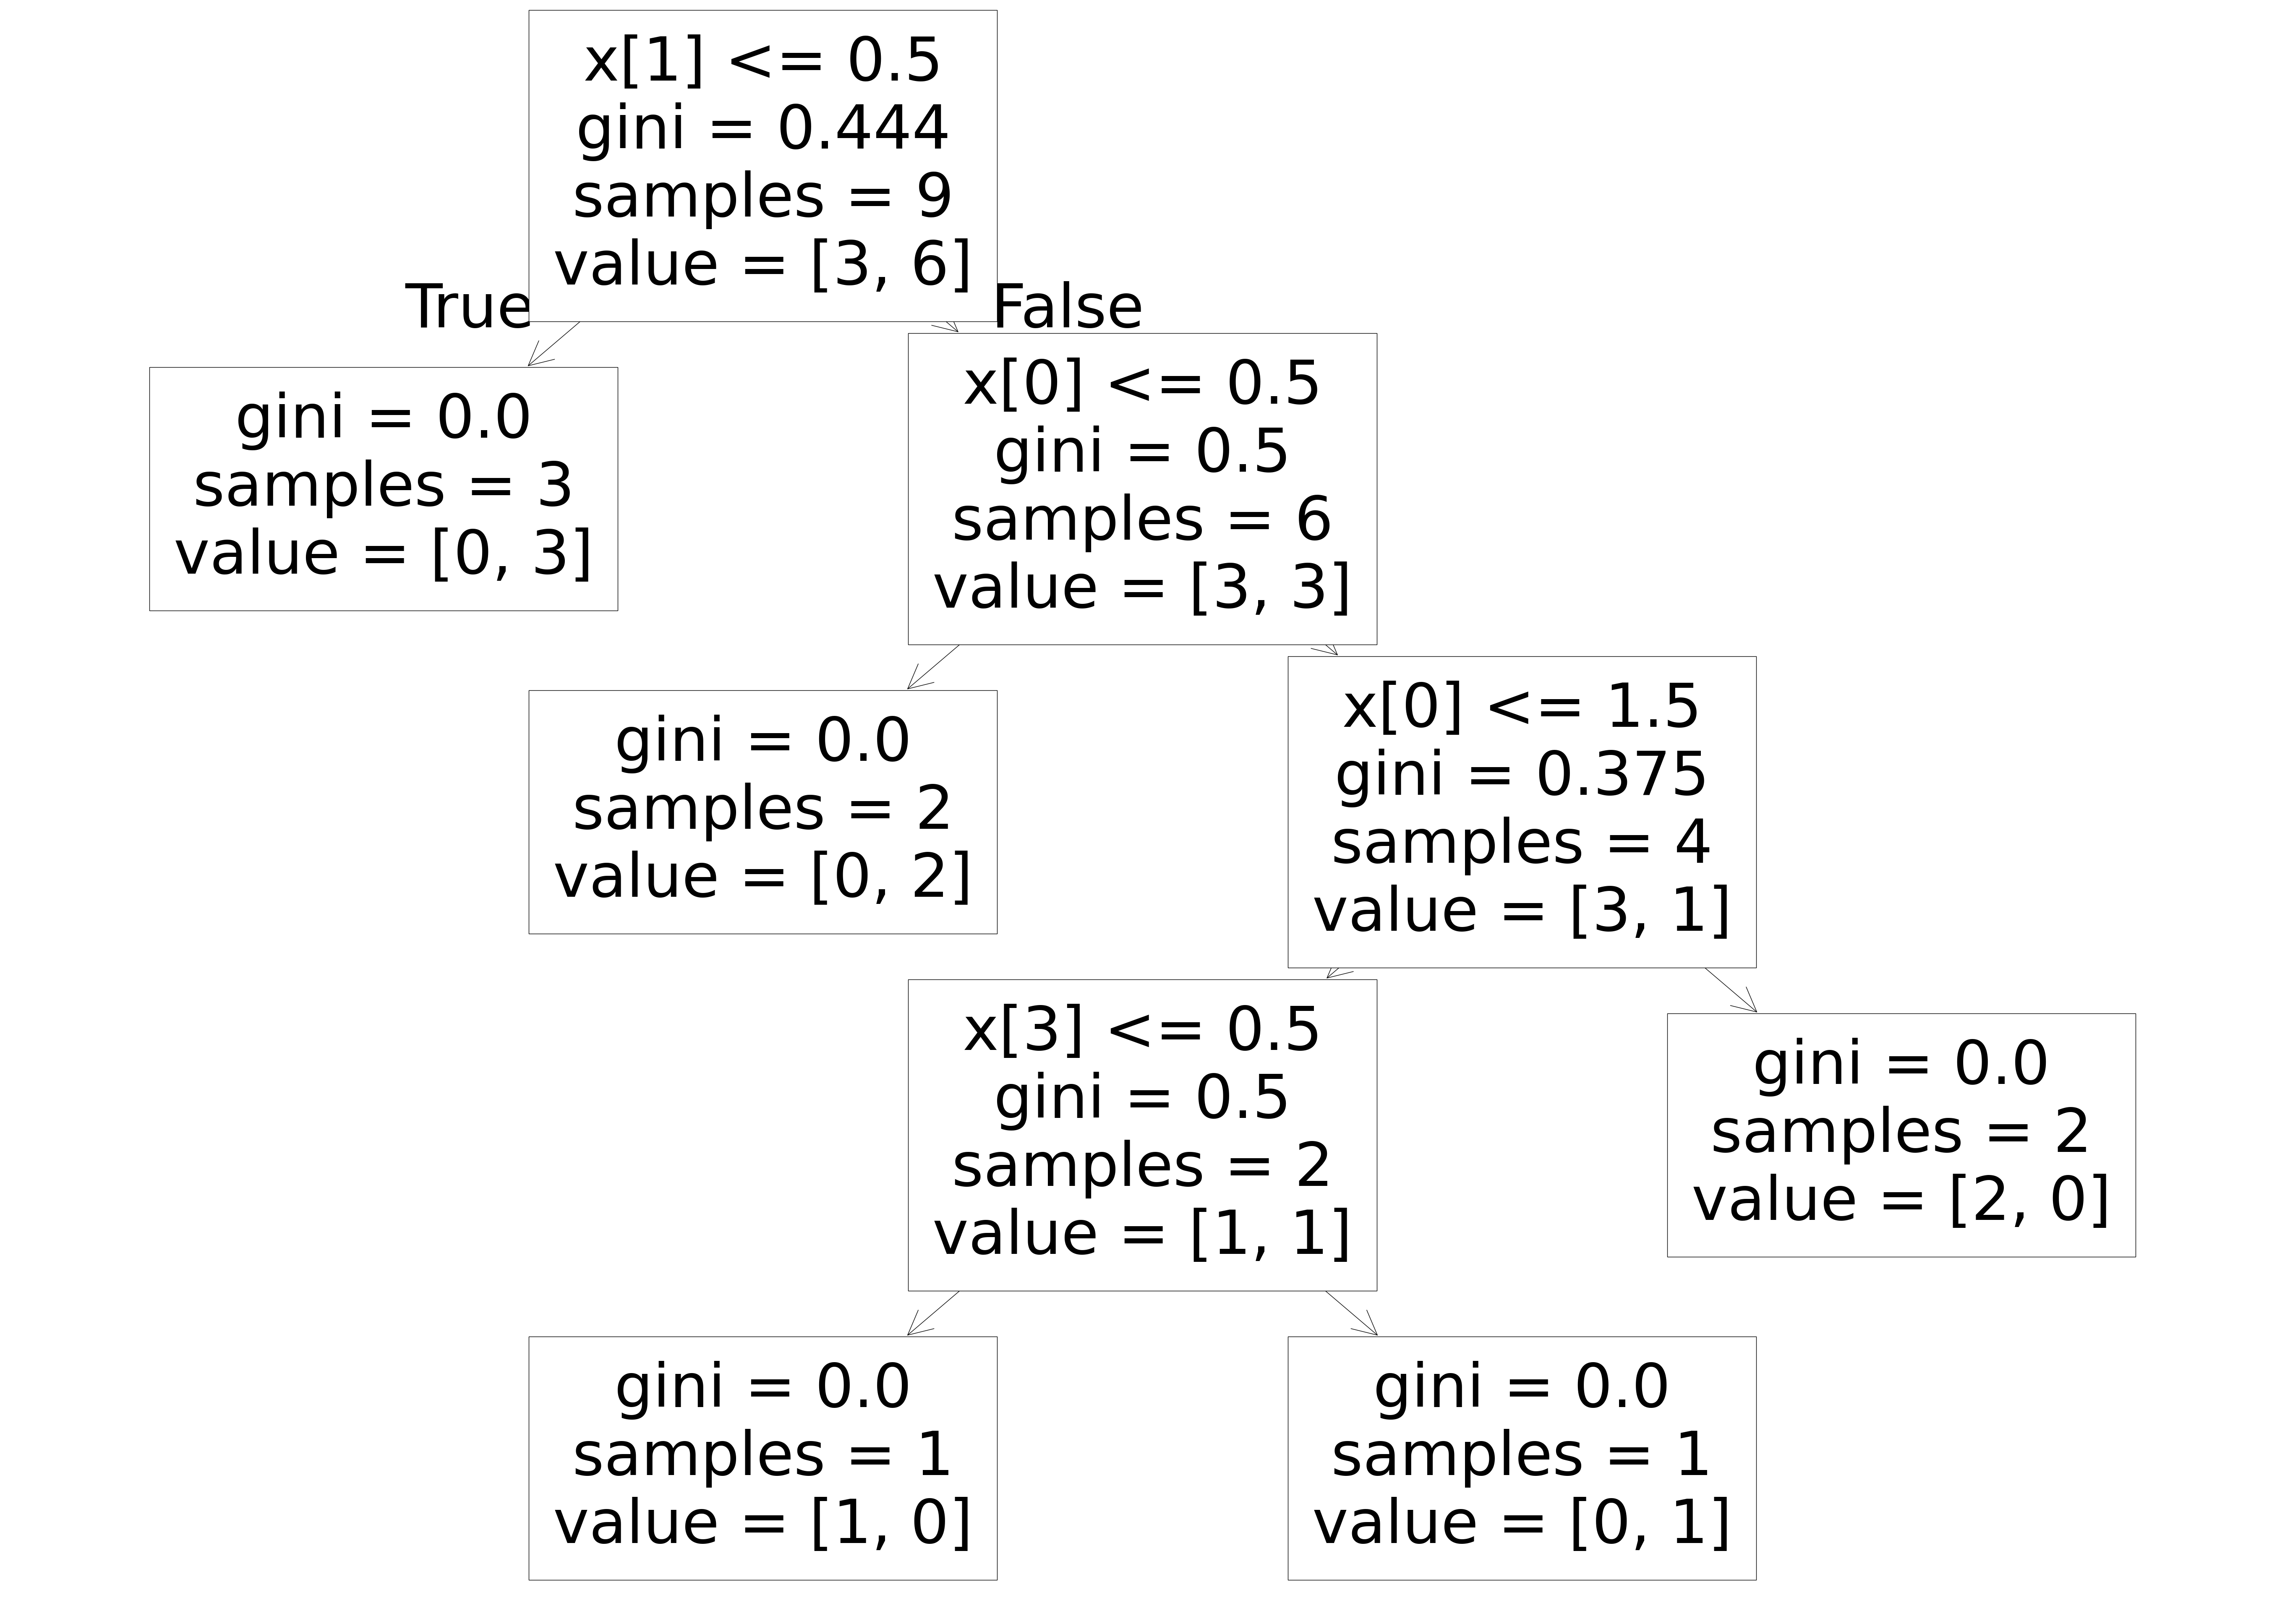

In [21]:
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(70,50))
plot_tree(decision_tree=dt,proportion=False)
plt.show()